# MMFDB · Burst Variance Analysis (BVA)

**BVA** asks whether a molecule's FRET *changes* while it is observed. Static
molecules sit on the shot-noise limit; dynamic ones rise above it. We simulate
the same two FRET states **static** and **dynamic**, store both in MMFDB, and
compare.

In [1]:
%matplotlib inline
import logging, warnings
for _n in ("numexpr", "mmfdb"):
    logging.getLogger(_n).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="nopython is set for njit")

import numpy as np
import matplotlib.pyplot as plt
from chisurf.plugins.burst.burst_analysis.api import BurstWorkflow
from chisurf.core.datastore import numeric_column


## Simulate static and dynamic molecules

In [2]:
wf = BurstWorkflow.demo()
static = wf.simulate(fret=(0.25, 0.75), exchange_rate=0.0, n_photons=300_000, seed=1)
dynamic = wf.simulate(fret=(0.25, 0.75), exchange_rate=5.0, n_photons=300_000, seed=2)
print("static handle :", static.handle[:8])
print("dynamic handle:", dynamic.handle[:8])

static handle : cfd66ce7
dynamic handle: 1ed1b575


## BVA plot

Each burst is a point; the red curve is the shot-noise limit. `dynamic_fraction`
is the share of bursts sitting above it.

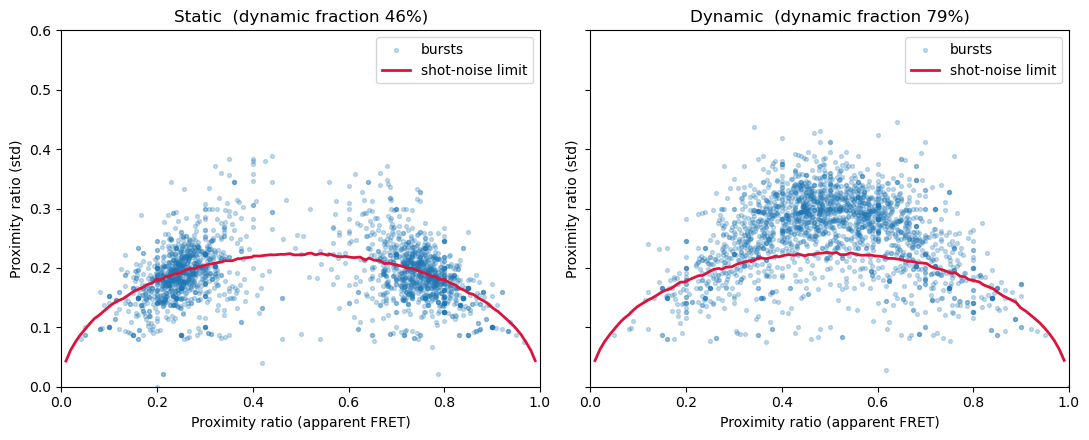

In [3]:
from emtk.figure import Figure

fig = Figure(1, 2, size=(1100, 450))   # the workflow draws on emtk panels
for col, (sim, title) in enumerate([(static, "Static"), (dynamic, "Dynamic")]):
    bva = wf.select_bursts(sim.handle, setup=sim.setup, min_photons=20).bva()
    ax = bva.plot(fig.ax(0, col))
    ax.set_title(f"{title}  (dynamic fraction {bva.dynamic_fraction:.0%})")
fig

## Proximity-ratio histograms

The same contrast as one-dimensional histograms: static molecules give two
separated peaks at the true efficiencies; fast exchange bridges them.

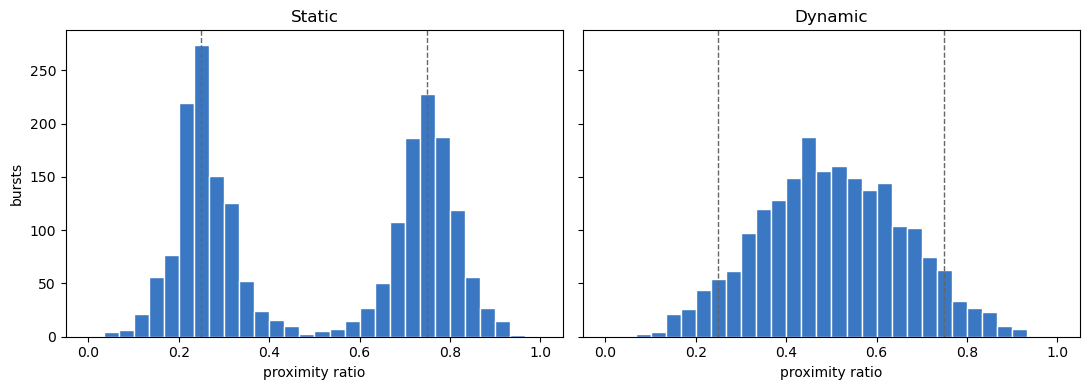

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
bins = np.linspace(0, 1, 31)
for ax, sim, title in [(axes[0], static, "Static"), (axes[1], dynamic, "Dynamic")]:
    pr = wf.select_bursts(sim.handle, setup=sim.setup, min_photons=20).bva().table
    pr = numeric_column(pr, "Proximity Ratio Mean")
    ax.hist(pr[np.isfinite(pr)], bins=bins, color="#3b78c3", edgecolor="white")
    for e in (0.25, 0.75):
        ax.axvline(e, color="0.4", ls="--", lw=1)
    ax.set_title(title); ax.set_xlabel("proximity ratio")
axes[0].set_ylabel("bursts")
fig.tight_layout(); plt.show()

In [5]:
wf.close()
print("Finished.")

Finished.
